In [1]:
!pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 16.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 17.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 15.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [seaborn]m7/8 [seaborn]ib]


In [2]:
import numpy as np
import torch
import torch.nn as nn
import torchvision.models as models
from torch.onnx import export


import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

from deepsparse.benchmark.benchmark_model import benchmark_model
import seaborn as sns
from sklearn.metrics import confusion_matrix

/home/rkaneko/.conda/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# モデル読み込み
pt_model_path = "dense.pt"   # 測りたいモデルに応じて変える
model = models.resnet18(weights = "IMAGENET1K_V1")
model.fc = nn.Linear(model.fc.in_features, 10)  # CIFAR-10 にあわせて出力層変更
model.load_state_dict(torch.load(pt_model_path))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [4]:
# テストデータセット作成
transform = transforms.Compose([transforms.Resize(224),
                                transforms.ToTensor(),
                                transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])   # 正規化したほうがいいらしい

testset = torchvision.datasets.CIFAR10(root = "./data", train = False, download = True, transform = transform)
testloader = DataLoader(testset, batch_size = 400, shuffle = False)

In [5]:
# cpuでの推論速度テスト
def pretty_benchmark(model_path, batch_size):
    result = benchmark_model(model_path, batch_size=batch_size)
    stats = result["benchmark_result"]

    print(f"モデル: {model_path}")
    print(f"バッチサイズ: {batch_size}")
    print(f"推論速度: {stats['items_per_sec']:.2f} items/sec")
    print(f"推論レイテンシ中央値: {stats['median']:.2f} ms")
    print(f"レイテンシ平均: {stats['mean']:.2f} ms")
    print(f"レイテンシ標準偏差: {stats['std']:.2f} ms")
    print(f"実行回数: {stats['iterations']} 回")


In [6]:
# GPUによる正解率テスト（cpuでもgpuでも正解か不正解かは変わらない）
def accuracy_test(model, test_loader, device):
    model.eval()
    model = model.to(device)

    with torch.no_grad():
      all_labels = []
      all_predictions = []

      for images, labels in test_loader:
        images = images.to(device)   # モデルに入力
        outputs = model(images)   # モデル出力を受け取る
        predicted = torch.max(outputs.data, 1)[1]   # 予測したラベル
        predicted = predicted.to('cpu')
        predicted = predicted.numpy()

        all_labels.extend(labels)   # 正解ラベル格納
        all_predictions.extend(predicted)   # 予測したラベル格納

    # 正解率の計算
    all_labels = np.array(all_labels)
    all_predictions = np.array(all_predictions)

    cm = confusion_matrix(all_labels, all_predictions)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted label') # X軸ラベル
    plt.ylabel('True label') # Y軸ラベル
    plt.title('Confusion Matrix') # タイトル
    plt.show()

    CAnumber=0
    for i in range(cm.shape[0]):
      CAnumber+=cm[i, i]
    print(f'正解率:{CAnumber/cm.sum()*100:.2f}%')

2025-10-04 21:17:57 deepsparse.benchmark.helpers INFO     Thread pinning to cores enabled


DeepSparse, Copyright 2021-present / Neuralmagic, Inc. version: 1.8.0 COMMUNITY | (e3778e93) (release) (optimized) (system=avx512, binary=avx512)
2025-10-04 21:17:58 deepsparse.benchmark.benchmark_model INFO     deepsparse.engine.Engine:
	onnx_file_path: ADMM_blocksparse_trained.onnx
	batch_size: 400
	num_cores: 4
	num_streams: 1
	scheduler: Scheduler.default
	fraction_of_supported_ops: 1.0
	cpu_avx_type: avx512
	cpu_vnni: False
2025-10-04 21:17:58 deepsparse.utils.onnx INFO     Generating input 'input', type = float32, shape = [400, 3, 224, 224]
2025-10-04 21:17:59 deepsparse.benchmark.benchmark_model INFO     Starting 'singlestream' performance measurements for 10 seconds


モデル: ADMM_blocksparse_trained.onnx
バッチサイズ: 400
推論速度: 516.47 items/sec
推論レイテンシ中央値: 764.40 ms
レイテンシ平均: 774.47 ms
レイテンシ標準偏差: 33.06 ms
実行回数: 13 回


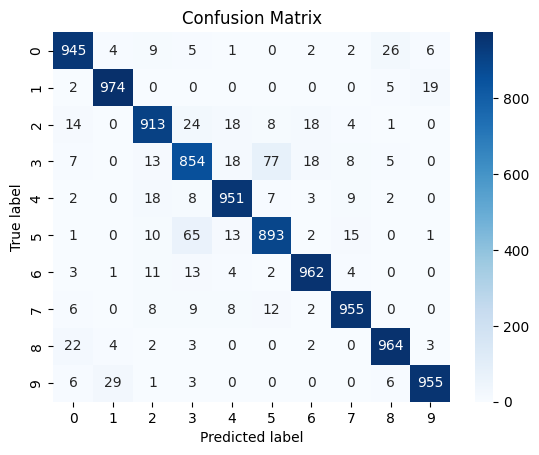

正解率:93.66%


In [7]:
# 推論速度と正解率の表示
onnx_model_path = "ADMM_blocksparse_trained.onnx"
pretty_benchmark(onnx_model_path, batch_size=400)
accuracy_test(model, testloader, device)

2025-07-19 15:51:01 deepsparse.benchmark.helpers INFO     Thread pinning to cores enabled
2025-07-19 15:51:04 deepsparse.benchmark.benchmark_model INFO     deepsparse.engine.Engine:
	onnx_file_path: blocksparse_trained2.onnx
	batch_size: 400
	num_cores: 20
	num_streams: 1
	scheduler: Scheduler.default
	fraction_of_supported_ops: 1.0
	cpu_avx_type: avx512
	cpu_vnni: True
2025-07-19 15:51:04 deepsparse.utils.onnx INFO     Generating input 'input', type = float32, shape = [400, 3, 224, 224]
2025-07-19 15:51:05 deepsparse.benchmark.benchmark_model INFO     Starting 'singlestream' performance measurements for 10 seconds


モデル: blocksparse_trained2.onnx
バッチサイズ: 400
推論速度: 714.69 items/sec
推論レイテンシ中央値: 558.40 ms
レイテンシ平均: 559.65 ms
レイテンシ標準偏差: 2.79 ms
実行回数: 18 回


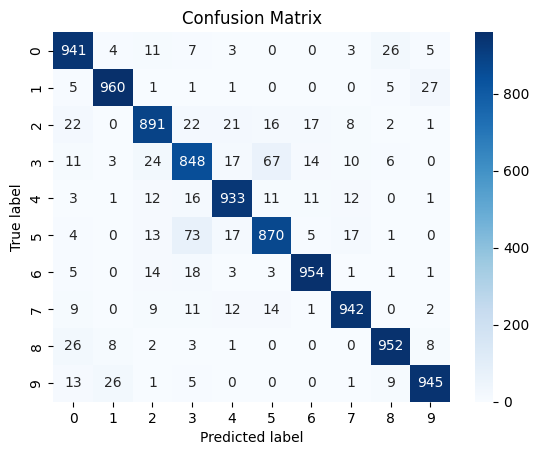

正解率:92.36%


In [ ]:
# 推論速度と正解率の表示
onnx_model_path = "blocksparse_trained2.onnx"
pretty_benchmark(onnx_model_path, batch_size=400)
accuracy_test(model, testloader, device)

2025-07-16 15:53:17 deepsparse.benchmark.helpers INFO     Thread pinning to cores enabled
2025-07-16 15:53:21 deepsparse.benchmark.benchmark_model INFO     deepsparse.engine.Engine:
	onnx_file_path: blocksparse_trained.onnx
	batch_size: 400
	num_cores: 20
	num_streams: 1
	scheduler: Scheduler.default
	fraction_of_supported_ops: 1.0
	cpu_avx_type: avx512
	cpu_vnni: True
2025-07-16 15:53:21 deepsparse.utils.onnx INFO     Generating input 'input', type = float32, shape = [400, 3, 224, 224]
2025-07-16 15:53:22 deepsparse.benchmark.benchmark_model INFO     Starting 'singlestream' performance measurements for 10 seconds


モデル: blocksparse_trained.onnx
バッチサイズ: 400
推論速度: 621.49 items/sec
推論レイテンシ中央値: 643.45 ms
レイテンシ平均: 643.60 ms
レイテンシ標準偏差: 4.22 ms
実行回数: 16 回


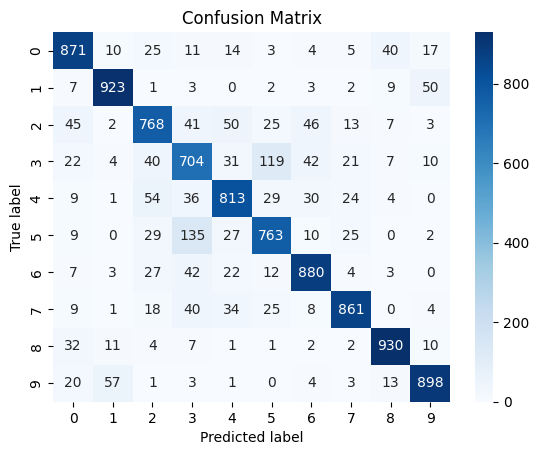

正解率:84.11%


In [ ]:
# 推論速度と正解率の表示
onnx_model_path = "blocksparse_trained.onnx"
pretty_benchmark(onnx_model_path, batch_size=400)
accuracy_test(model, testloader, device)

2025-07-23 16:07:29 deepsparse.benchmark.helpers INFO     Thread pinning to cores enabled
2025-07-23 16:07:33 deepsparse.benchmark.benchmark_model INFO     deepsparse.engine.Engine:
	onnx_file_path: sparse_trained2.onnx
	batch_size: 400
	num_cores: 20
	num_streams: 1
	scheduler: Scheduler.default
	fraction_of_supported_ops: 1.0
	cpu_avx_type: avx512
	cpu_vnni: True
2025-07-23 16:07:33 deepsparse.utils.onnx INFO     Generating input 'input', type = float32, shape = [400, 3, 224, 224]
2025-07-23 16:07:33 deepsparse.benchmark.benchmark_model INFO     Starting 'singlestream' performance measurements for 10 seconds


モデル: sparse_trained2.onnx
バッチサイズ: 400
推論速度: 466.08 items/sec
推論レイテンシ中央値: 858.20 ms
レイテンシ平均: 858.21 ms
レイテンシ標準偏差: 0.81 ms
実行回数: 12 回


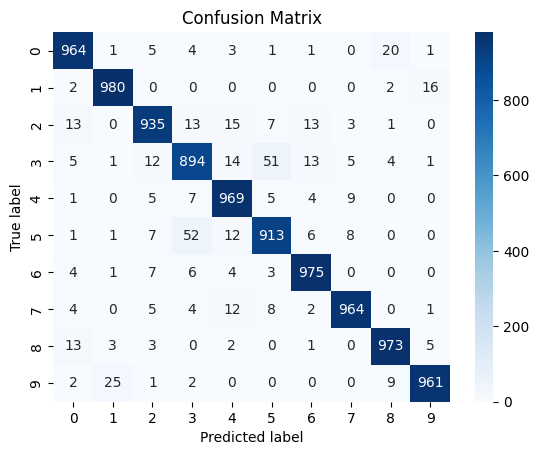

正解率:95.28%


In [9]:
# 推論速度と正解率の表示
onnx_model_path = "sparse_trained2.onnx"
pretty_benchmark(onnx_model_path, batch_size=400)
accuracy_test(model, testloader, device)

2025-10-05 18:08:59 deepsparse.benchmark.helpers INFO     Thread pinning to cores enabled
DeepSparse, Copyright 2021-present / Neuralmagic, Inc. version: 1.8.0 COMMUNITY | (e3778e93) (release) (optimized) (system=avx512, binary=avx512)
2025-10-05 18:09:01 deepsparse.benchmark.benchmark_model INFO     deepsparse.engine.Engine:
	onnx_file_path: dense.onnx
	batch_size: 400
	num_cores: 4
	num_streams: 1
	scheduler: Scheduler.default
	fraction_of_supported_ops: 1.0
	cpu_avx_type: avx512
	cpu_vnni: False
2025-10-05 18:09:01 deepsparse.utils.onnx INFO     Generating input 'input', type = float32, shape = [400, 3, 224, 224]
2025-10-05 18:09:01 deepsparse.benchmark.benchmark_model INFO     Starting 'singlestream' performance measurements for 10 seconds


モデル: dense.onnx
バッチサイズ: 400
推論速度: 290.51 items/sec
推論レイテンシ中央値: 1375.09 ms
レイテンシ平均: 1376.88 ms
レイテンシ標準偏差: 3.35 ms
実行回数: 8 回


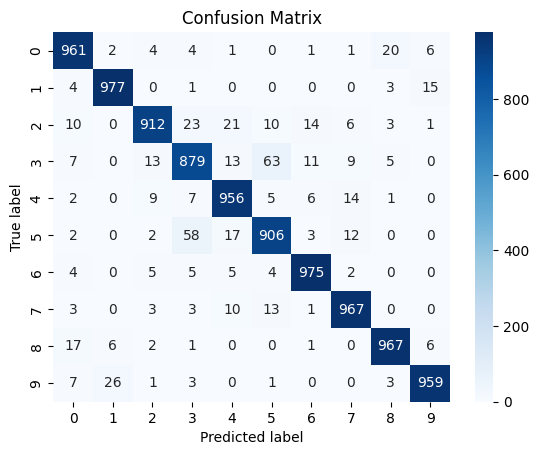

正解率:94.59%


In [7]:
# 推論速度と正解率の表示
onnx_model_path = "dense.onnx"
pretty_benchmark(onnx_model_path, batch_size=400)
accuracy_test(model, testloader, device)